   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

各特征均值与标准差
      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
mean           5.843333          3.057333           3.758000          1.199333
std            0.828066          0.435866           1.765298          0.762238
标准化后均值(应接近0): [-0. -0. -0. -0.]
标准化后方差(应接近1): [1. 1. 1. 1.]
各主成分解释方差比: [0.72962445 0.22850762 0.03668922 0.00517871]
累积解释方差比: [0.72962445 0.95813207 0.99482129 1.        ]


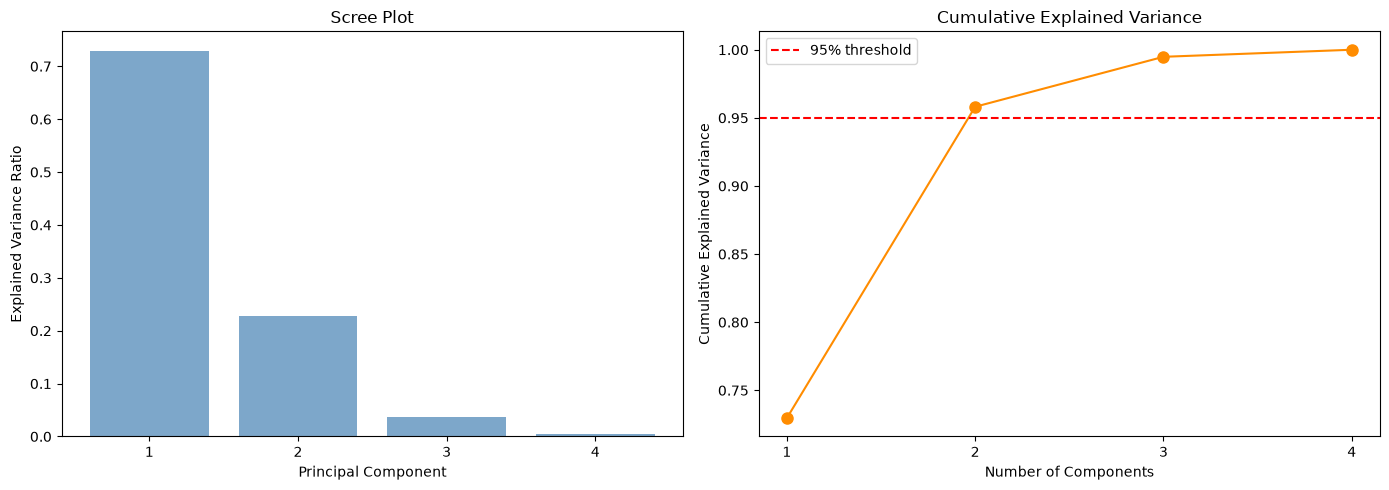

降维后的数据形状: (150, 2)
第一主成分方向(载荷): [ 0.52106591 -0.26934744  0.5804131   0.56485654]
第二主成分方向(载荷): [0.37741762 0.92329566 0.02449161 0.06694199]
                        PC1       PC2
sepal length (cm)  0.521066  0.377418
sepal width (cm)  -0.269347  0.923296
petal length (cm)  0.580413  0.024492
petal width (cm)   0.564857  0.066942


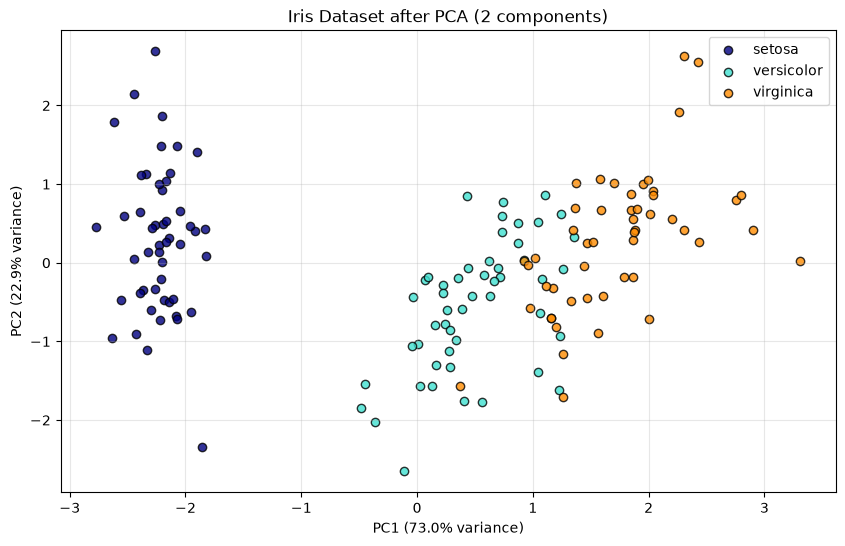

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
plt.rcParams['figure.figsize'] = (10,6)
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names
df = pd.DataFrame(X,columns = feature_names)
df['species'] = [target_names[i] for i in y]
print(df.head())
print("\n各特征均值与标准差")
print(df.describe().loc[['mean','std']])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("标准化后均值(应接近0):",X_scaled.mean(axis=0).round(2))
print("标准化后方差(应接近1):",X_scaled.std(axis=0).round(2))
pca_full = PCA()
pca_full.fit(X_scaled)
explained_variance_ratio = pca_full.explained_variance_ratio_
cumsum_variance_ratio = np.cumsum(explained_variance_ratio)
print("各主成分解释方差比:",explained_variance_ratio)
print("累积解释方差比:",cumsum_variance_ratio)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))

# 左图：单独方差（碎石图）
ax1.bar(range(1,5), explained_variance_ratio, alpha=0.7, color='steelblue')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Scree Plot')
ax1.set_xticks([1,2,3,4])

# 右图：累积方差
ax2.plot(range(1,5), cumsum_variance_ratio, 'o-', markersize=8, color='darkorange')
ax2.axhline(y=0.95, color='r', linestyle='--', label='95% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
ax2.set_xticks([1,2,3,4])

plt.tight_layout()
plt.show()
k = 2 
pca = PCA(n_components = k)
X_pca = pca.fit_transform(X_scaled)
print("降维后的数据形状:",X_pca.shape)
print("第一主成分方向(载荷):",pca.components_[0])
print("第二主成分方向(载荷):",pca.components_[1])
loadings = pd.DataFrame(
    pca.components_.T,
    columns = ['PC1','PC2'],
    index = feature_names
)
print(loadings)
colors = ['navy','turquoise','darkorange']
plt.figure()
for i,color,target_name in zip([0,1,2],colors,target_names):
    plt.scatter(X_pca[y==i, 0], X_pca[y==i, 1],
                color=color, alpha=0.8, label=target_name, edgecolor='k')
plt.xlabel(f'PC1 ({explained_variance_ratio[0]:.1%} variance)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]:.1%} variance)')
plt.title('Iris Dataset after PCA (2 components)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()